## Visualization

In [1]:
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [2]:
# import utilitaires
#
%matplotlib inline

import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

from pathlib import Path

In [3]:
# import package develope pour le projet + config
#
import ffury
from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)
from ffury.optional.development.dataset import IndexedDataset

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

In [4]:
# load datasets
dataset_train = IndexedDataset.create(config, DatasetType.TRAIN)
dataset_train_csv = config.get_csv_filename(DatasetType.TRAIN)
dataset_train_csv = pd.read_csv(dataset_train_csv)

In [13]:
import librosa as rosa
import matplotlib.ticker as mticker
from IPython.display import Audio

from ffury.optional.development.misc.hdf5 import open_file
from ffury.optional.development.transforms.properties import (
    _SPECTROGRAM,
    _SPECTROGRAM_MASK
)

def colorize_mask(mask, height):
    # appliquer couleur au masque
    image = np.zeros( (mask.shape[0], 3) )

    image[mask == 0] = [1, 0, 0]
    image[mask != 0] = [0, 1, 0]

    # convertir en image avec bonne resolution
    image = image[np.newaxis, ...]
    return np.tile(image, (height, 1, 1))

def specshow(data, data_mask=None, data_mask_alpha=0.1, start_index=0):
    if not start_index is None:
        def update_ticks(x, loc):
            return x + start_index

        plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(update_ticks))

    plt.gca().imshow(data,
                     cmap="gray",
                     aspect="auto",
                     interpolation="nearest",
                     vmin=-1, # spectrogram a un range [0, -1]
                     vmax=0)

    if not data_mask is None:
        mask = colorize_mask(data_mask, data.shape[0])
        plt.gca().imshow(mask,
                         aspect="auto",
                         interpolation="nearest",
                         alpha=data_mask_alpha)

def plot_group(path, start, stop, data_mask_alpha=0.1):
    file = str(path)
    file = file.replace(str(config.paths.BUILD_DIR), str(config.paths.DATA_DIR))
    file = file.replace(_SPECTROGRAM, "audio")
    file = file.replace(".hdf5", ".ogg")

    print(path)
    print(file)

    y, sr = rosa.load(file)

    fig = plt.figure(figsize=(12, 2))
    rosa.display.waveshow(y,
                          sr=sr,
                          ax=plt.gca())
    plt.xlabel("")
    plt.show()

    display(Audio(data=y, rate=sr))

    with open_file(path, "r") as file:
        spectrogram_data = file[_SPECTROGRAM]
        spectrogram_mask_data = file[_SPECTROGRAM_MASK]

        fig = plt.figure(figsize=(12, 2))
        specshow(spectrogram_data[:, start:stop],
                 spectrogram_mask_data[start:stop],
                 data_mask_alpha)
        plt.tight_layout()
        plt.show()

In [14]:
# inspection visuelle
print(dataset_train.species_label)
print(dataset_train.species_short_label)

['Barn Swallow', 'Common Buzzard', 'Eurasian Hoopoe', 'Thrush Nightingale', 'Willow Warbler']
['barswa', 'combuz1', 'hoopoe', 'thrnig1', 'wlwwar']


In [15]:
files = Path.joinpath(config.paths.BUILD_DIR, _SPECTROGRAM, "barswa").glob('*.hdf5')
files = list(files)

/Users/jfgagnon/Projects/FeatheredFury/build/spectrogram/barswa/XC177243.hdf5
/Users/jfgagnon/Projects/FeatheredFury/data/audio/barswa/XC177243.ogg


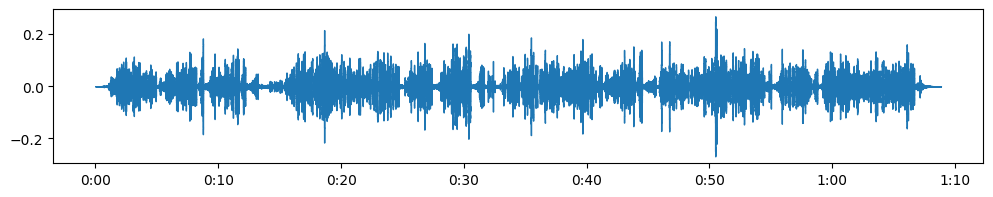

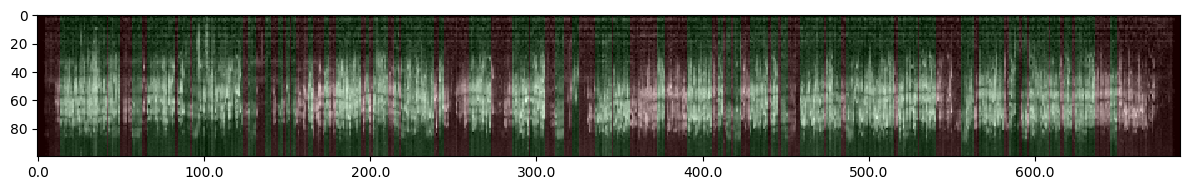

In [16]:
plot_group(random.choice(files),
           0, -1,
           0.1)